# Ligand-Receptor plotting

In [1]:
import squidpy as sq
import numpy as np
import pandas as pd
from anndata import AnnData
from typing import Mapping, Sequence
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

Load pre-processed squidpy dataset

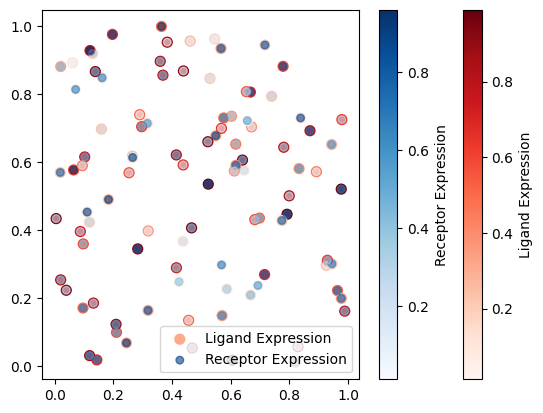

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors

# Generate synthetic data
np.random.seed(0)
x = np.random.rand(100)
y = np.random.rand(100)
ligand_expression = np.random.rand(100)
receptor_expression = np.random.rand(100)

# Create figure and scatter plot
fig, ax = plt.subplots()
scatter = ax.scatter(x, y, c=ligand_expression, cmap='Reds', label='Ligand Expression', s=50)

# Set up colorbars
norm_ligand = colors.Normalize(vmin=ligand_expression.min(), vmax=ligand_expression.max())
cbar_ligand = fig.colorbar(cm.ScalarMappable(norm=norm_ligand, cmap='Reds'), ax=ax, orientation='vertical')
cbar_ligand.set_label('Ligand Expression')

# Create a second scatter overlay with the receptor expression colors
scatter_receptor = ax.scatter(x, y, c=receptor_expression, cmap='Blues', s=30, alpha=0.6, label='Receptor Expression')

# Set up the second colorbar for receptor expression
norm_receptor = colors.Normalize(vmin=receptor_expression.min(), vmax=receptor_expression.max())
cbar_receptor = fig.colorbar(cm.ScalarMappable(norm=norm_receptor, cmap='Blues'), ax=ax, orientation='vertical')
cbar_receptor.set_label('Receptor Expression')

# Show plot
plt.legend()
plt.show()


In [15]:
# load the pre-processed dataset
adata = sq.datasets.merfish()
adata

AnnData object with n_obs × n_vars = 73655 × 161
    obs: 'Cell_ID', 'Animal_ID', 'Animal_sex', 'Behavior', 'Bregma', 'Centroid_X', 'Centroid_Y', 'Cell_class', 'Neuron_cluster_ID', 'batch'
    uns: 'Cell_class_colors'
    obsm: 'spatial', 'spatial3d'

In [16]:
subadata = adata[adata.obs.Bregma == -9]

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/squidpy/pl/_color_utils.py:28: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  target.uns[color_key] = source.uns[color_key]
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


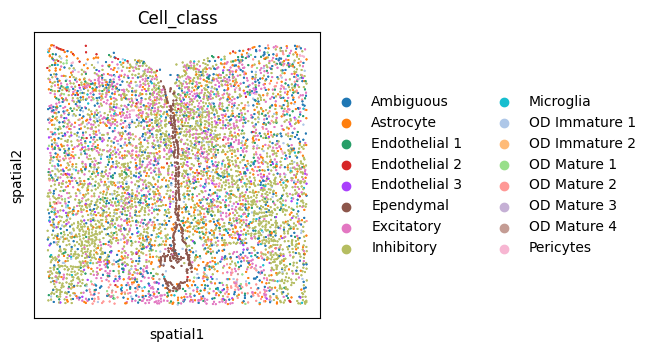

In [5]:
sq.pl.spatial_scatter(
  subadata  , shape=None, color="Cell_class", size=1
)

Ligand-Receptor squidpy analysis to find interacting LR pairs.

In [6]:
res = sq.gr.ligrec(
    subadata,
    n_perms=1000,
    cluster_key="Cell_class",
    copy=True,
    use_raw=False,
    transmitter_params={"categories": "ligand"},
    receiver_params={"categories": "receptor"},
)

100%|██████████| 1000/1000 [00:04<00:00, 212.53permutation/s]


In [7]:
res["means"].head()

cluster_1     Ambiguous                                                      \
cluster_2     Ambiguous Astrocyte Endothelial 1 Endothelial 2 Endothelial 3   
source target                                                                 
CCK    CCKBR   0.328673  0.129803       0.11499       0.10844      0.167904   
CRH    CRHR1   0.330943  0.135669      0.102548      0.103251      0.095919   
       CRHR2   0.169217  0.057456      0.087599       0.11273      0.114682   
UCN3   CRHR2   0.168458  0.056697       0.08684       0.11197      0.113923   
PENK   OPRD1   0.618841   0.19278      0.180996      0.147629      0.263203   

cluster_1                                                              ...  \
cluster_2     Ependymal Excitatory Inhibitory Microglia OD Immature 1  ...   
source target                                                          ...   
CCK    CCKBR   3.492219   0.640666   0.407462  0.171014      0.228355  ...   
CRH    CRHR1   0.085575   0.325875   0.525499  0.132429      0.213631  ...   
       CRHR2     0.0769   0.319316   0.209749  0.058387      0.093995  ...   
UCN3   CRHR2   0.076141   0.318557    0.20899  0.057627      0.093236  ...   
PENK   OPRD1   0.177052   0.422948   0.697729   0.26276      0.358137  ...   

cluster_1      Pericytes                                                   \
cluster_2     Excitatory Inhibitory Microglia OD Immature 1 OD Immature 2   
source target                                                               
CCK    CCKBR    0.637581   0.404378   0.16793      0.225271      1.991701   
CRH    CRHR1    0.322135    0.52176   0.12869      0.209892      0.444345   
       CRHR2    0.315577    0.20601  0.054647      0.090255             0   
UCN3   CRHR2      0.3163   0.206733   0.05537      0.090979             0   
PENK   OPRD1    0.389515   0.664296  0.229328      0.324704      0.248829   

cluster_1                                                                
cluster_2     OD Mature 1 OD Mature 2 OD Mature 3 OD Mature 4 Pericytes  
source target                                                            
CCK    CCKBR     0.105735    0.141991    0.240101    0.112945  0.222412  
CRH    CRHR1     0.068997    0.106763           0           0  0.189138  
       CRHR2     0.017338    0.048731           0    0.110323  0.132343  
UCN3   CRHR2     0.018061    0.049454           0    0.111046  0.133067  
PENK   OPRD1     0.096002    0.082657           0    0.062896  0.148498  

[5 rows x 256 columns]

In [38]:
import squidpy as sq
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors

def plot_lr(adata, ligand, receptor):
    # uppercase ligand, receptor and gene name strings
    adata.var_names = adata.var_names.str.upper()
    ligand = ligand.upper()
    receptor = receptor.upper()

    # Validate inputs
    if ligand not in adata.var_names:
        raise ValueError(f"Ligand gene '{ligand}' not found in adata.var_names.")
    if receptor not in adata.var_names:
        raise ValueError(f"Receptor gene '{receptor}' not found in adata.var_names.")
    
    # Extract ligand and receptor expression
    ligand_expression = (adata.X[:, adata.var_names == ligand].todense())
    receptor_expression = (adata.X[:, adata.var_names == receptor].todense())

    adata.obs['ligand_expression'] = ligand_expression
    adata.obs['receptor_expression'] = receptor_expression

    # Set up the plot
    fig, ax = plt.subplots()

    # Plot ligand expression
    sq.pl.spatial_scatter(
        adata,
        color='ligand_expression',
        cmap='Reds',
        ax=ax,
        shape=None,
        size=20,
    )

    # Add ligand colorbar
    norm_ligand = colors.Normalize(vmin=ligand_expression.min(), vmax=ligand_expression.max())
    cbar_ligand = fig.colorbar(cm.ScalarMappable(norm=norm_ligand, cmap='Reds'), ax=ax, orientation='vertical')
    cbar_ligand.set_label('Ligand Expression')

    # Overlay receptor expression with a second plot, using transparency for visual distinction
    sq.pl.spatial_scatter(
        adata,
        color='receptor_expression',
        cmap='Blues',
        ax=ax,
        alpha=0.3,
        shape=None,
        size=20,
    )

    # Add receptor colorbar
    norm_receptor = colors.Normalize(vmin=receptor_expression.min(), vmax=receptor_expression.max())
    cbar_receptor = fig.colorbar(cm.ScalarMappable(norm=norm_receptor, cmap='Blues'), ax=ax, orientation='vertical')
    cbar_receptor.set_label('Receptor Expression')

    # Display the plot
    plt.show()


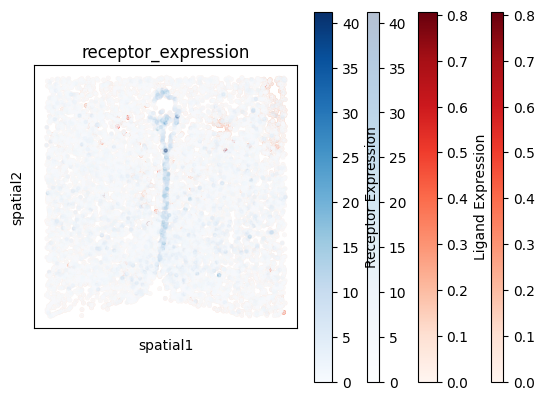

In [39]:
ligand="CCK"
receptor="CCKBR"

plot_lr(subadata, ligand, receptor)

In [60]:
def ligand_receptor_interaction(
    adata: AnnData | Mapping[str, pd.DataFrame],
    ligand: str | Sequence[str],
    receptor: str | Sequence[str],
    threshold: float = 0.3,
    color_map: str = 'seismic'
) -> None:
    """
    Plot ligand-receptor expression on spatial data with separate color scales in the same plot.

    Parameters
    ----------
    adata
        AnnData object or a dictionary containing the ligand-receptor data.
    ligand
        Gene name for the ligand.
    receptor
        Gene name for the receptor.
    threshold
        Expression threshold to display; below this, cells are colored grey.
    color_maps
        Name for diverging colormap from matplotlib colormap libaries
    """
    # uppercase ligand, receptor and gene name strings
    adata.var_names = adata.var_names.str.upper()
    ligand = ligand.upper()
    receptor = receptor.upper()

    # Validate inputs
    if not (0 <= threshold <= 1):
        raise ValueError(f"Threshold must be within range 0 to 1.")
    if ligand not in adata.var_names:
        raise ValueError(f"Ligand gene '{ligand}' not found in adata.var_names.")
    if receptor not in adata.var_names:
        raise ValueError(f"Receptor gene '{receptor}' not found in adata.var_names.")
    
    # TODO: assume normalized LR values
    # TODO: how do I change it to work efficiently for compressed sparse matrix 

    # Extract ligand and receptor expression
    ligand_expr = adata.X[:, adata.var_names == ligand].copy()
    receptor_expr = adata.X[:, adata.var_names == receptor].copy()

    # Apply threshold: set values below threshold to NaN (to color them grey later)
    ligand_expr[threshold > ligand_expr] = np.nan
    receptor_expr[threshold > receptor_expr] = np.nan

    # Apply the seismic colormap to the combined expression
    cmap = plt.get_cmap(color_map)

    # Create a color array for all cells
    cell_colors = [None] * ligand_expr.shape[0]

    # Iterate over each row (cell) in the ligand expression sparse matrix
    for i in range(ligand_expr.shape[0]):
        ligand_value = ligand_expr.data[i]

        # If the ligand is expressed in this cell, apply the color map
        if not np.isnan(ligand_value):
            cell_colors[i] = cmap(-ligand_value)  # Apply colormap for ligand (mapped to negative)

    # Iterate over each row (cell) in the receptor expression sparse matrix
    for i in range(receptor_expr.shape[0]):
        receptor_values = receptor_expr.data[i]

        # If the receptor is expressed in this cell, apply the color map
        if len(receptor_values) > 0:
            receptor_value = receptor_values[0]  # CSR is efficient for row access, so we directly access the value
            if not np.array_equal(cell_colors[i], (0, 0, 0, 0)):  # Check if the cell already has a ligand color
                cell_colors[i] = (211/255, 211/255, 211/255, 1.0)  # Mix colors (set to light grey)
            else:
                cell_colors[i] = cmap(receptor_value)  # Apply colormap for receptor (mapped to positive)

    # Set remaining uncolored cells (still [0, 0, 0, 0]) to grey
    cell_colors[np.all(np.nan)] = (211/255, 211/255, 211/255, 1.0)

    adata.obs['colors'] = cell_colors

    # Create a scatter plot with custom RGB values
    sq.pl.spatial_scatter(
        adata,
        shape=None,
        color='colors',
        title=f'Ligand ({ligand}) and Receptor ({receptor}) Expression',
        size=20,
        palette=[cell_colors]
    )

0.34471422
0.7939899
0.34060243
0.33508834
0.5034881
0.45680022
0.32376227
0.80659163
0.45124254
0.4546885
0.6859318
0.460293
0.3550334
0.32568395
0.31180716
0.4606629
0.33816603


/tmp/ipykernel_4068460/2900626674.py:45: SparseEfficiencyWarning: Comparing a sparse matrix with a scalar greater than zero using < is inefficient, try using >= instead.
  ligand_expr[threshold > ligand_expr] = np.nan
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
/tmp/ipykernel_4068460/2900626674.py:46: SparseEfficiencyWarning: Comparing a sparse matrix with a scalar greater than zero using < is inefficient, try using >= instead.
  receptor_expr[threshold > receptor_expr] = np.nan
/tmp/ipykernel_4068460/2900626674.py:79: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index
  cell_colors[np.all(np.nan)] = (211/255, 211/255, 211/255, 1.0)
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/G

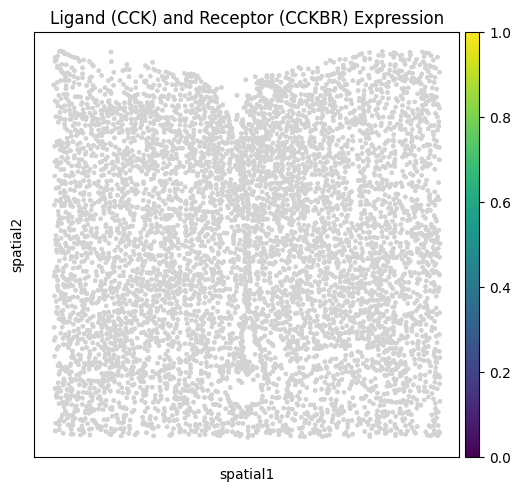

In [61]:
ligand_receptor_interaction(
    adata=subadata,
    ligand="CCK",
    receptor="CCKBR",
    threshold=0.3,
)